[EDA 探索性資料分析目標]
1. 觀察 A 醫院的細菌物種樣本數，並視覺化顯示最多的前 15 個物種。
2. 鎖定樣本數前 3 多的細菌物種，分別取其測試次數最多的 15 種藥物，
   計算並繪製其 R (抗藥)、I (中等)、S (敏感) 的比例分佈。

正在讀取 CSV 檔案...
✅ CSV 中總共有 30069 筆樣本紀錄。

正在掃描 Raw 資料夾...
✅ Raw 資料夾中總共有 42888 個質譜檔案。

📊 比對結果報告
🎯 完美吻合 (CSV 有紀錄 且 有質譜檔): 30069 筆
⚠️ 找不到檔案 (CSV有，但硬碟沒檔): 0 筆
👻 幽靈檔案 (硬碟有檔，但CSV沒紀錄): 12819 筆
=== 細菌物種數量統計 ===
species
Staphylococcus epidermidis    2554
Staphylococcus aureus         2191
Escherichia coli              1970
Pseudomonas aeruginosa        1463
Enterococcus faecalis         1336
Klebsiella pneumoniae         1099
Gardnerella vaginalis         1053
Propionibacterium acnes        739
Candida albicans               735
Streptococcus agalactiae       669
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_24220\3423730999.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=species_counts.head(15).values, y=species_counts.head(15).index, palette='viridis')


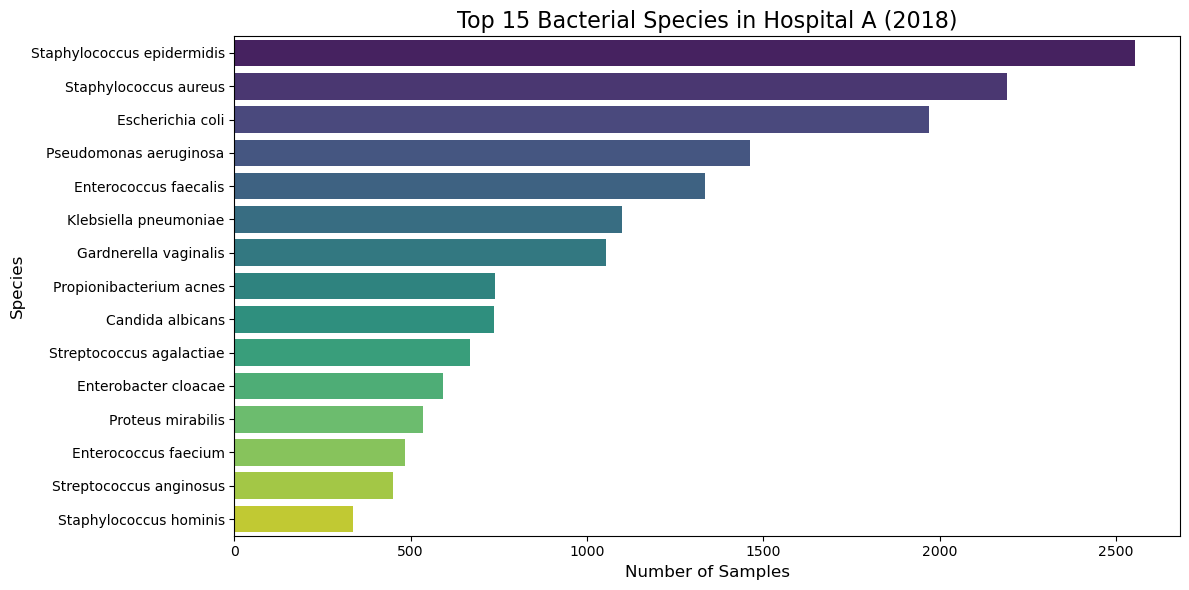

正在繪製 Staphylococcus epidermidis 的抗藥性比例圖...


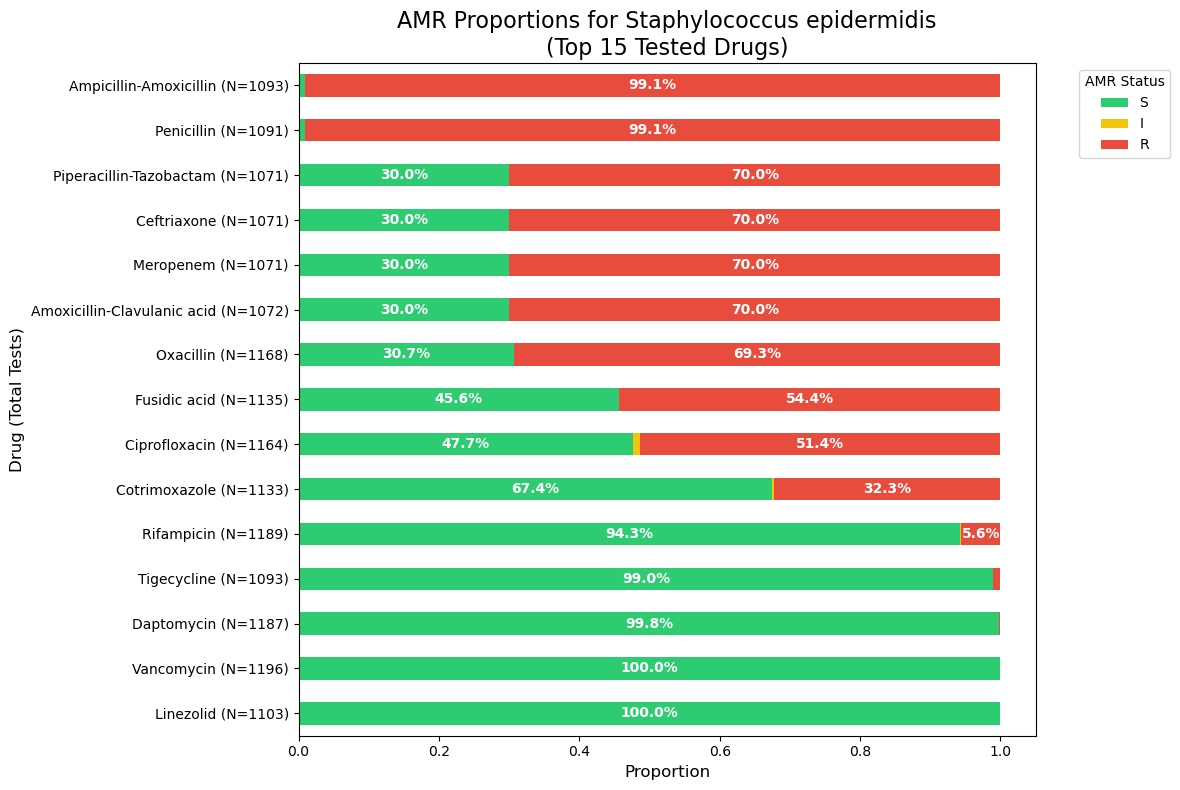

正在繪製 Staphylococcus aureus 的抗藥性比例圖...


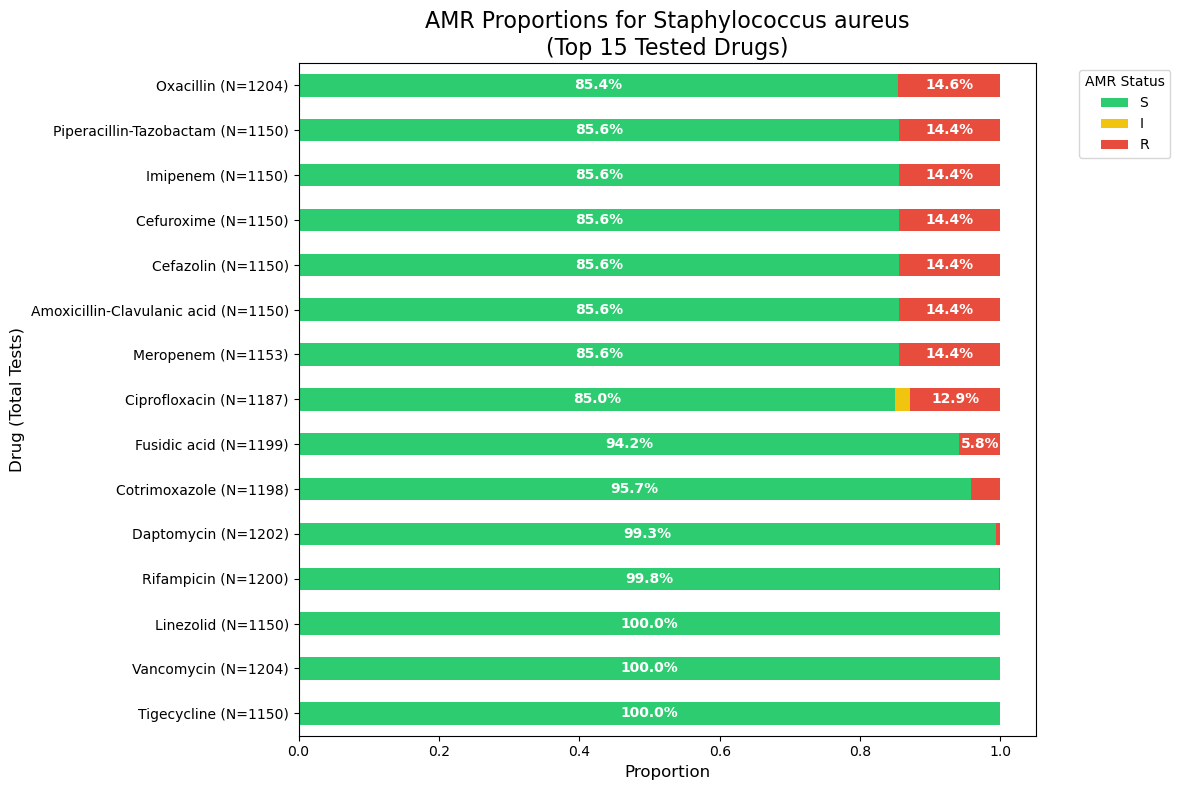

正在繪製 Escherichia coli 的抗藥性比例圖...


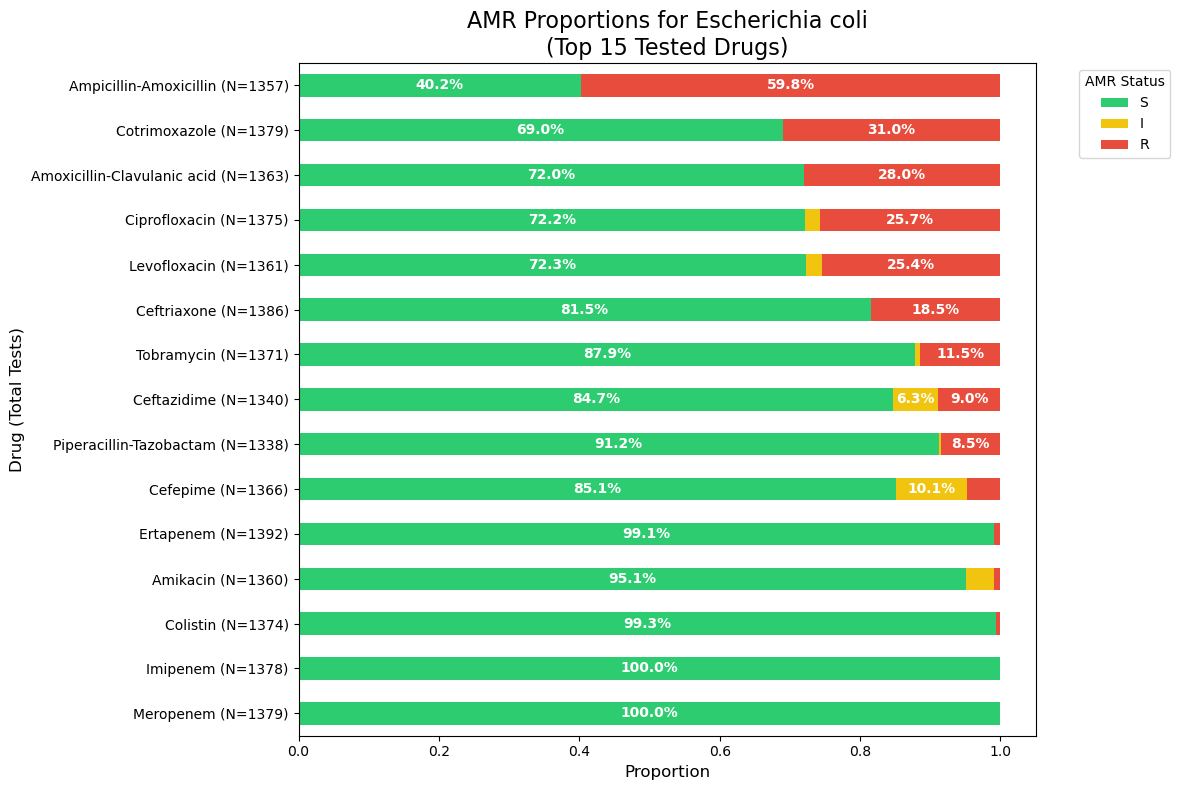

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# 1. 設定你的路徑
# ==========================================
csv_path = r"D:\DRIAMS_dataset\DRIAMS-A\id\2018\2018_clean.csv"  # 你的 metadata CSV 檔路徑
raw_folder_path = r"D:\DRIAMS_dataset\DRIAMS-A\raw\2018" # 存放 .txt 質譜數據的資料夾路徑

# ==========================================
# 2. 讀取 CSV 中的樣本編號 (code)
# ==========================================
print("正在讀取 CSV 檔案...")
df = pd.read_csv(csv_path)

# 假設 CSV 中代表樣本 ID 的欄位叫做 'code'
# 我們將它轉為字串並放入 Set (集合) 中，以利後續的高速比對
csv_codes = set(df['code'].astype(str))
print(f"✅ CSV 中總共有 {len(csv_codes)} 筆樣本紀錄。")

# ==========================================
# 3. 讀取 Raw 資料夾中的實際檔案名稱
# ==========================================
print("\n正在掃描 Raw 資料夾...")
raw_dir = Path(raw_folder_path)

# 使用 rglob('*.txt') 可以連同子資料夾內的 .txt 一起找出來
# 如果你的檔案沒有副檔名或是其他格式(如 .csv, .mzML)，請自行更改 '*.txt'
raw_files = list(raw_dir.rglob('*.txt'))

# 萃取檔名 (不含副檔名)。例如 '00a34ab1.txt' 會被萃取出 '00a34ab1'
raw_codes = set(file.stem for file in raw_files)
print(f"✅ Raw 資料夾中總共有 {len(raw_codes)} 個質譜檔案。")

# ==========================================
# 4. 進行集合比對 (Intersection & Difference)
# ==========================================
print("\n" + "="*40)
print("📊 比對結果報告")
print("="*40)

# 取交集 (Intersection)：兩邊都有的，這才是你真正能用的資料！
valid_samples = csv_codes.intersection(raw_codes)
print(f"🎯 完美吻合 (CSV 有紀錄 且 有質譜檔): {len(valid_samples)} 筆")

# 取差集 (Difference)：找出有問題的資料
missing_in_raw = csv_codes - raw_codes
print(f"⚠️ 找不到檔案 (CSV有，但硬碟沒檔): {len(missing_in_raw)} 筆")

missing_in_csv = raw_codes - csv_codes
print(f"👻 幽靈檔案 (硬碟有檔，但CSV沒紀錄): {len(missing_in_csv)} 筆")

# ==========================================
# 5. 輸出真正可用的乾淨資料表 (可選)
# ==========================================
# 如果你想直接把沒有檔案的爛資料從 dataframe 中剔除，可以這樣做：
df_clean = df[df['code'].isin(valid_samples)]
# df_clean.to_csv('driams_b_clean_matched.csv', index=False)
# print(f"\n已將吻合的 {len(df_clean)} 筆資料另存為乾淨的 CSV 檔！")

# 假設這是你的藥物欄位列表
drug_columns = [
    'Penicillin', 'Ceftriaxone', 'Vancomycin', 'Piperacillin-Tazobactam', 'Ciprofloxacin', 
    'Cefepime', 'Cotrimoxazole', 'Meropenem', 'Moxifloxacin', 'Amoxicillin-Clavulanic acid', 
    'Colistin', 'Tobramycin', 'Ceftazidime', 'Ceftolozane-Tazobactam', 'Ceftazidime-Avibactam', 
    'Ceftobiprole', 'Quinolones', 'Tigecycline', 'Levofloxacin', 'Fosfomycin', 'Amikacin', 
    'Imipenem', 'Minocycline', 'Gentamicin', 'Ceftarolin', 'Ampicillin-Sulbactam', 
    'Gentamicin_high_level', 'Aztreonam', 'Clindamycin', 'Amoxicillin', 'Metronidazole', 
    'Daptomycin', 'Ampicillin-Amoxicillin', 'Caspofungin', 'Voriconazole', 'Posaconazole', 
    'Amphotericin B', 'Itraconazole', 'Fluconazole', 'Erythromycin', 'Doxycycline', 
    'Isavuconazole', 'Anidulafungin', '5-Fluorocytosine', 'Micafungin', 'Tetracycline', 
    'Azithromycin', 'Ertapenem', 'Fosfomycin-Trometamol', 'Norfloxacin', 'Cefpodoxime', 
    'Nitrofurantoin', 'Aminoglycosides', 'Chloramphenicol', 'Rifampicin_1mg-l', 'Rifampicin', 
    'Linezolid', 'Amoxicillin-Clavulanic acid_uncomplicated_HWI', 'Strepomycin_high_level', 
    'Teicoplanin', 'Cefuroxime', 'Penicillin_with_endokarditis', 'Penicillin_without_endokarditis', 
    'Meropenem_with_meningitis', 'Meropenem_without_meningitis', 'Cefazolin', 'Oxacillin', 
    'Fusidic acid', 'Streptomycin', 'Isoniazid_.1mg-l', 'Pyrazinamide', 'Ethambutol_5mg-l', 
    'Cefixime', 'Mupirocin', 'Vancomycin_GRD', 'Teicoplanin_GRD', 'Cefoxitin_screen', 
    'Penicillin_with_meningitis', 'Clarithromycin', 'Penicillin_with_other_infections', 
    'Penicillin_with_pneumonia', 'Meropenem_with_pneumonia'
]

# ==========================================
# 1. 統計每個細菌物種的樣本數量
# ==========================================
print("=== 細菌物種數量統計 ===")
species_counts = df_clean['species'].value_counts()
print(species_counts.head(10)) # 印出前 10 名

# 繪製前 15 名最常見的細菌物種長條圖
plt.figure(figsize=(12, 6))
sns.barplot(x=species_counts.head(15).values, y=species_counts.head(15).index, palette='viridis')
plt.title('Top 15 Bacterial Species in Hospital A (2018)', fontsize=16)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Species', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 2. 計算特定細菌對各藥物的抗藥性與敏感性比例
# ==========================================
# 步驟 A: 將寬資料轉換為長資料 (Melt)
# 這樣可以把所有藥物欄位整併成 'Drug' 欄位，測驗結果變成 'AMR_Status' 欄位
# 並且只保留資料庫中確實有這 82 種藥物欄位的資料
available_drugs = [col for col in drug_columns if col in df_clean.columns]
df_long = pd.melt(df_clean, id_vars=['code', 'species'], 
                  value_vars=available_drugs, 
                  var_name='Drug', 
                  value_name='AMR_Status')

# 步驟 B: 清除沒有測驗結果的資料 (Drop NaN)
# 臨床上不是每種細菌都會測所有藥物，未測驗的會是 NaN
df_long_clean = df_long.dropna(subset=['AMR_Status'])

# 步驟 C: 只過濾出 R, S, I 的合法標籤 (排除可能有的奇怪字元)
df_long_clean = df_long_clean[df_long_clean['AMR_Status'].isin(['R', 'S', 'I'])]

# 步驟 D: 撰寫一個函數，方便你觀察「指定細菌」的抗藥性比例
# 步驟 D: 撰寫一個函數，方便你觀察「指定細菌」的抗藥性比例與總樣本數
# 步驟 D: 撰寫一個函數，方便你觀察「指定細菌」的抗藥性比例與總樣本數
def plot_amr_proportion_for_species(target_species, top_n_drugs=15):
    """
    繪製特定細菌在最常被測試的 top_n_drugs 種藥物上的 R/I/S 比例堆疊長條圖，
    並在 Y 軸標籤顯示該藥物的總測試數量 (N)。
    """
    # 篩選該細菌的資料
    df_species = df_long_clean[df_long_clean['species'] == target_species]
    
    if df_species.empty:
        print(f"找不到 {target_species} 的資料。")
        return
        
    # 計算每種藥物在該細菌中被測試的「總次數」，選出最常被測試的前 N 種藥物
    drug_test_counts = df_species['Drug'].value_counts()
    top_drugs = drug_test_counts.head(top_n_drugs).index
    
    # 只保留這些常見藥物的測試結果
    df_top_drugs = df_species[df_species['Drug'].isin(top_drugs)]
    
    # 建立交叉表 (Crosstab) 並計算比例 (normalize='index' 使每列總和為 1)
    amr_crosstab = pd.crosstab(df_top_drugs['Drug'], df_top_drugs['AMR_Status'], normalize='index')
    
    # 確保 R, I, S 三個欄位都存在，若無則補 0
    for status in ['R', 'I', 'S']:
        if status not in amr_crosstab.columns:
            amr_crosstab[status] = 0
            
    # 按照抗藥性 (R) 的比例由高到低排序，圖表會更美觀且具洞察力
    amr_crosstab = amr_crosstab.sort_values(by='R', ascending=True)

    # =============== 【這就是你漏掉的關鍵邏輯】 ===============
    # 重新命名 Y 軸的標籤，把「總測試數量」加到抗生素名稱後面
    # 例如：從 "Penicillin" 變成 "Penicillin (N=1250)"
    new_labels = [f"{drug} (N={drug_test_counts[drug]})" for drug in amr_crosstab.index]
    amr_crosstab.index = new_labels
    # ==========================================================

    # 繪製堆疊長條圖 (Stacked Bar Chart)
    # 顏色配置：R (紅色/抗藥), I (黃色/中等), S (綠色/敏感)
    color_map = {'R': '#e74c3c', 'I': '#f1c40f', 'S': '#2ecc71'}
    
    ax = amr_crosstab[['S', 'I', 'R']].plot(kind='barh', stacked=True, figsize=(12, 8), 
                                            color=[color_map.get(x, '#333333') for x in ['S', 'I', 'R']])
    
    plt.title(f'AMR Proportions for {target_species}\n(Top {top_n_drugs} Tested Drugs)', fontsize=16)
    plt.xlabel('Proportion', fontsize=12)
    plt.ylabel('Drug (Total Tests)', fontsize=12)
    plt.legend(title='AMR Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 在長條圖上標示百分比數字 (大於 5% 才標示以免太擠)
    for c in ax.containers:
        ax.bar_label(c, fmt=lambda x: f'{x*100:.1f}%' if x > 0.05 else '', label_type='center', color='white', weight='bold')
        
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. 呼叫函數進行觀察
# ==========================================
for i in range(3):
    target_bug = species_counts.index[i] 
    print(f"正在繪製 {target_bug} 的抗藥性比例圖...")
    plot_amr_proportion_for_species(target_bug, top_n_drugs=15)

[EDA 探索性資料分析目標]
1. 觀察 B 醫院的細菌物種樣本數，並視覺化顯示最多的前 15 個物種。
2. 鎖定樣本數前 3 多的細菌物種，分別取其測試次數最多的 15 種藥物，
   計算並繪製其 R (抗藥)、I (中等)、S (敏感) 的比例分佈。

篩選Staphylococcus epidermidis 的 raw 和 preprocessed 的樣本

In [2]:
import pandas as pd
import shutil
from pathlib import Path

# ==========================================
# 1. 設定你的路徑與目標物種
# ==========================================
target_species = "Staphylococcus epidermidis"  # 你想抓取的目標細菌
csv_path = r"D:\DRIAMS_dataset\DRIAMS-A\id\2018\2018_clean.csv"  # 你的 CSV 檔案路徑

# 設定來源資料夾 (Raw 與 Preprocessed)
raw_source_dir = r"D:\DRIAMS_dataset\DRIAMS-A\raw\2018"
bin_source_dir = r"D:\DRIAMS_dataset\DRIAMS-A\binned_6000\2018"
preprocessed_source_dir = r"D:\DRIAMS_dataset\DRIAMS-A\preprocessed\2018" 

# 設定要存入的新資料夾路徑 (程式會自動幫你建立這些資料夾)
raw_dest_dir = r"D:\DRIAMS_dataset\filtered_A_S_epidermidis\raw"
bin_dest_dir = r"D:\DRIAMS_dataset\filtered_A_S_epidermidis\binned_6000"
preprocessed_dest_dir = r"D:\DRIAMS_dataset\filtered_A_S_epidermidis\preprocessed"

# ==========================================
# 2. 從 CSV 中找出所有該物種的樣本編號
# ==========================================
print(f"正在讀取 CSV 檔案並尋找 {target_species}...")
df = pd.read_csv(csv_path)

# 篩選出目標物種的資料列
df_target = df[df['species'] == target_species]

# 提取 'code' 欄位，轉為字串並存成集合 (Set)，大幅提升後續比對速度
target_codes = set(df_target['code'].astype(str))
print(f"✅ 在 CSV 中共找到 {len(target_codes)} 筆 {target_species} 的紀錄。\n")

# ==========================================
# 3. 定義一個用來「比對並複製檔案」的函數
# ==========================================
def filter_and_copy_files(source_path, dest_path, valid_codes):
    source_dir = Path(source_path)
    dest_dir = Path(dest_path)
    
    # 檢查來源資料夾是否存在
    if not source_dir.exists():
        print(f"❌ 找不到來源資料夾: {source_path}，已跳過。")
        return
        
    # 如果目標資料夾不存在，就自動建立它 (parents=True 代表會連同上層目錄一起建)
    dest_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"📂 開始處理資料夾: {source_dir.name} ...")
    
    # 找出來源資料夾內所有的 .txt 檔案
    all_txt_files = list(source_dir.rglob('*.txt'))
    
    copied_count = 0
    # 為了不破壞原本的集合，複製一份名單來追蹤哪些檔案沒被找到
    remaining_codes = valid_codes.copy() 
    
    for file_path in all_txt_files:
        file_stem = file_path.stem # 取得檔名 (不含 .txt)
        
        # 如果這個檔名在我們的目標名單中
        if file_stem in remaining_codes:
            # 設定新的檔案路徑
            new_file_path = dest_dir / file_path.name
            
            # 執行複製 (使用 copy2 可以保留檔案原本的建立/修改時間等 Metadata)
            shutil.copy2(file_path, new_file_path)
            
            copied_count += 1
            remaining_codes.remove(file_stem) # 從名單中剔除已找到的
            
    # 輸出結果報告
    print(f"   ➔ 成功複製了 {copied_count} 個檔案至 {dest_dir}")
    if len(remaining_codes) > 0:
        print(f"   ⚠️ 有 {len(remaining_codes)} 筆樣本在 CSV 中有紀錄，但在該資料夾找不到實體檔案。")
    print("-" * 50)

# ==========================================
# 4. 執行函數：分別複製 Raw 與 Preprocessed 檔案
# ==========================================
print("=" * 50)
print("🚀 開始執行檔案複製任務")
print("=" * 50)

# 執行 Raw 資料夾的複製
filter_and_copy_files(raw_source_dir, raw_dest_dir, target_codes)
# 執行 Preprocessed 資料夾的複製
filter_and_copy_files(preprocessed_source_dir, preprocessed_dest_dir, target_codes)
# 執行 bin 資料夾的複製
filter_and_copy_files(bin_source_dir, bin_dest_dir, target_codes)
#

print("🎉 所有複製任務已完成！")

正在讀取 CSV 檔案並尋找 Staphylococcus epidermidis...
✅ 在 CSV 中共找到 2554 筆 Staphylococcus epidermidis 的紀錄。

🚀 開始執行檔案複製任務
📂 開始處理資料夾: 2018 ...
   ➔ 成功複製了 2554 個檔案至 D:\DRIAMS_dataset\filtered_A_S_epidermidis\raw
--------------------------------------------------
📂 開始處理資料夾: 2018 ...
   ➔ 成功複製了 2554 個檔案至 D:\DRIAMS_dataset\filtered_A_S_epidermidis\preprocessed
--------------------------------------------------
📂 開始處理資料夾: 2018 ...
   ➔ 成功複製了 2554 個檔案至 D:\DRIAMS_dataset\filtered_A_S_epidermidis\binned_6000
--------------------------------------------------
🎉 所有複製任務已完成！


In [3]:
import pandas as pd
from pathlib import Path

# ==========================================
# 1. 設定路徑與目標
# ==========================================
target_species = "Staphylococcus epidermidis"
original_csv_path = r"D:\DRIAMS_dataset\DRIAMS-A\id\2018\2018_clean.csv"

# 設定新 CSV 要存檔的路徑 (建議直接存在你剛剛建立的獨立資料夾裡)
new_csv_dir = r"D:\DRIAMS_dataset\filtered_A_S_epidermidis"
new_csv_path = rf"{new_csv_dir}\2018_S_epidermidis_metadata.csv"

# ==========================================
# 2. 讀取、篩選並儲存
# ==========================================
print(f"正在讀取原始 CSV...")
df = pd.read_csv(original_csv_path)

# 篩選出只有表皮葡萄球菌的列 (Rows)
df_target = df[df['species'] == target_species]

# 檢查一下目標資料夾是否存在，不在就建一個
Path(new_csv_dir).mkdir(parents=True, exist_ok=True)

# 將篩選後的結果存成新的 CSV 檔案
# 💡 注意：index=False 非常重要！這會防止 Pandas 把最左邊的「列編號(0, 1, 2...)」當成新欄位寫進去
df_target.to_csv(new_csv_path, index=False, encoding='utf-8')

print(f"🎉 大功告成！已將 {len(df_target)} 筆 {target_species} 的紀錄存至:")
print(f"➔ {new_csv_path}")

正在讀取原始 CSV...
🎉 大功告成！已將 2554 筆 Staphylococcus epidermidis 的紀錄存至:
➔ D:\DRIAMS_dataset\filtered_A_S_epidermidis\2018_S_epidermidis_metadata.csv
